# Intermittent demand: genuine zeros, stockouts and availability scenarios

A zero can mean that nobody wanted a product or that it was unavailable. We model
these mechanisms explicitly with a Bernoulli occurrence process and a Gamma
positive quantity. This is a **hurdle model for continuous quantities** such as kg;
for integer unit sales use an appropriate positive count distribution instead.

This is a generative alternative inspired by Juan Orduz's
[TSB](https://github.com/juanitorduz/numpyro_forecast/blob/main/docs/examples/tsb.ipynb)
and [availability TSB](https://github.com/juanitorduz/numpyro_forecast/blob/main/docs/examples/availability_tsb.ipynb)
examples. It is not a literal TSB implementation: time-varying occurrence probabilities
are regression parameters, and each forecast samples an actual occurrence and quantity.
The additive-error `ssoe` helper in the [ARMA example](arma.ipynb) serves a different
model family.

In [1]:
import os

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import xarray as xr

from pymc_forecast import (
    HMCForecaster,
    evaluate_forecast,
    predict,
)

SMOKE = os.getenv("PYMC_FORECAST_SMOKE_TEST") == "1"
SEED = 2026
rng = np.random.default_rng(SEED)
DRAWS, TUNE, CHAINS = (25, 25, 1) if SMOKE else (600, 800, 2)
N_PRED = 50 if SMOKE else 800
plt.rcParams.update({"figure.figsize": (10, 4), "figure.dpi": 110})
print(
    "Execution mode:", "CI smoke check; do not interpret fit quality" if SMOKE else "full example"
)

Execution mode: full example


## Simulate demand before observing sales

Three products have different demand frequencies. The third gradually loses demand.
Availability is simulated independently of latent demand here, so stockout periods
provide no evidence about the occurrence probability. Real stockouts caused by high
demand require an inventory/censoring model; this example assumes a known external
availability mask and no partial-day capacity cap.

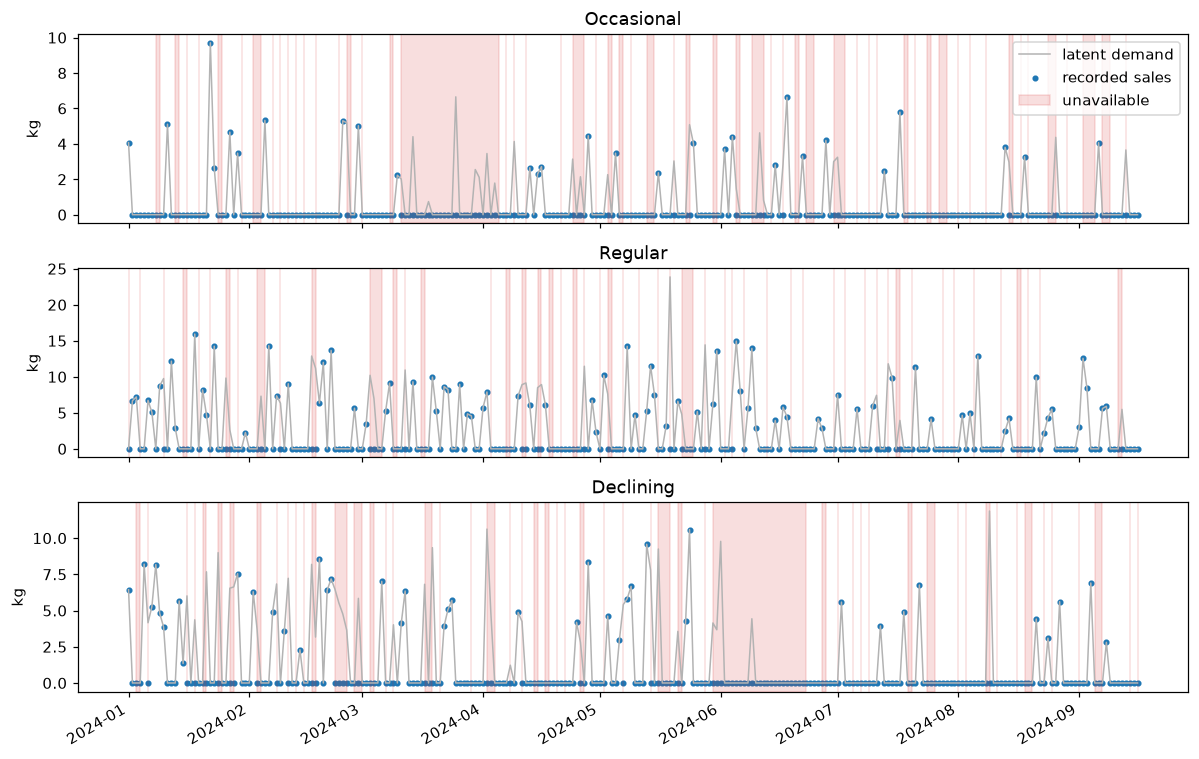

In [2]:
n_train, horizon = 220, 40
n = n_train + horizon
products = ["Occasional", "Regular", "Declining"]
time = pd.date_range("2024-01-01", periods=n, freq="D")
t_scaled = np.arange(n) / n_train
intercept = np.array([-1.3, -0.2, 0.3])
slope = np.array([0.0, 0.0, -2.2])
probability = 1 / (1 + np.exp(-(intercept + t_scaled[:, None] * slope)))
size_mean = np.array([4.0, 8.0, 6.0])
shape = 5.0
latent_demand = (rng.random((n, 3)) < probability) * rng.gamma(shape, size_mean / shape, (n, 3))
availability = (rng.random((n, 3)) > np.array([0.4, 0.3, 0.35])).astype(float)
availability[70:95, 0] = 0
availability[150:175, 2] = 0
sales = xr.DataArray(
    availability * latent_demand,
    dims=("time", "product"),
    coords={"time": time, "product": products},
)
inputs = xr.DataArray(
    np.stack([np.broadcast_to(t_scaled[:, None], (n, 3)), availability], axis=1),
    dims=("time", "input", "product"),
    coords={"time": time, "input": ["elapsed", "available"], "product": products},
)
train = sales.isel(time=slice(n_train))
train_inputs = inputs.isel(time=slice(n_train))
truth_sales = sales.isel(time=slice(n_train, None)).rename(time="time_future")
truth_demand = xr.DataArray(
    latent_demand[n_train:],
    dims=("time_future", "product"),
    coords={"time_future": time[n_train:], "product": products},
)
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for j, ax in enumerate(axes):
    ax.plot(time, latent_demand[:, j], color="0.7", lw=1, label="latent demand")
    ax.scatter(time, sales[:, j], s=9, label="recorded sales")
    ax.fill_between(
        time,
        0,
        1,
        where=availability[:, j] == 0,
        transform=ax.get_xaxis_transform(),
        color="C3",
        alpha=0.15,
        label="unavailable",
    )
    ax.set(ylabel="kg", title=products[j])
axes[0].legend(loc="upper right")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## Model occurrence and positive quantity separately

For product $s$, $p_{t,s}=\operatorname{sigmoid}(a_s+b_s t)$ and
$Y_{t,s}\sim\operatorname{HurdleGamma}(\psi=A_{t,s}p_{t,s},m_s,k_s)$.
Thus $E[Y_{t,s}]=A_{t,s}p_{t,s}m_s$. At zero availability the observation is
certainly zero and contributes no information about demand. At full availability,
zeros are genuine non-occurrence events. The probability always lies in $[0,1]$,
and positive quantities are never negative.

The model receives named inputs; the only future values it reads are elapsed time
and the availability scenario. `predict` receives the expected sales on the outcome
scale, which makes its `mu_future` output directly interpretable in kg.

In [3]:
def demand_model(h, covariates):
    elapsed = pt.as_tensor_variable(covariates.sel(input="elapsed").values)
    available = pt.as_tensor_variable(covariates.sel(input="available").values)
    intercept = pm.Normal("occurrence_intercept", 0, 1.5, dims="product")
    slope = pm.Normal("occurrence_slope", 0, 1.5, dims="product")
    size_mean = pm.LogNormal("positive_mean", np.log(5), 0.8, dims="product")
    shape = pm.LogNormal("positive_shape", np.log(4), 0.6, dims="product")
    psi = available * pm.math.sigmoid(intercept + elapsed * slope)
    expectation = psi * size_mean

    def likelihood(name, expected, dims, observed):
        segment = slice(0, h.t_obs) if dims[0] == "time" else slice(h.t_obs, None)
        return pm.HurdleGamma(
            name,
            psi=psi[segment],
            alpha=shape,
            beta=shape / size_mean,
            dims=dims,
            observed=observed,
        )

    predict(h, likelihood, expectation)


fc = HMCForecaster(
    demand_model,
    train,
    train_inputs,
    draws=DRAWS,
    tune=TUNE,
    chains=CHAINS,
    random_seed=SEED,
    progressbar=False,
    sample_kwargs={"target_accept": 0.9},
)
az.summary(fc.idata, var_names=["occurrence_intercept", "occurrence_slope", "positive_mean"])

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [occurrence_intercept, occurrence_slope, positive_mean, positive_shape]


Sampling 2 chains for 800 tune and 600 draw iterations (1_600 + 1_200 draws total) took 2 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
occurrence_intercept[Occasional],-1.104,0.368,-1.794,-0.395,0.010,0.011,1460.0,671.0,1.00
occurrence_intercept[Regular],-0.020,0.290,-0.545,0.517,0.008,0.007,1176.0,938.0,1.00
occurrence_intercept[Declining],-0.132,0.332,-0.739,0.506,0.008,0.011,1614.0,930.0,1.01
occurrence_slope[Occasional],-0.444,0.646,-1.732,0.738,0.017,0.019,1403.0,866.0,1.00
occurrence_slope[Regular],-0.475,0.495,-1.371,0.488,0.015,0.014,1139.0,761.0,1.00
occurrence_slope[Declining],-1.694,0.629,-2.844,-0.406,0.016,0.020,1506.0,766.0,1.01
positive_mean[Occasional],4.154,0.340,3.536,4.812,0.009,0.010,1466.0,933.0,1.00
positive_mean[Regular],7.533,0.441,6.658,8.322,0.011,0.016,1786.0,713.0,1.00
positive_mean[Declining],5.736,0.387,5.013,6.440,0.010,0.012,1667.0,969.0,1.00


## Two scenarios from the same posterior

We use the simulated future availability as a *specified scenario*, not as information
that would ordinarily be known at ordering time. Full availability describes latent
unconstrained demand under this model. Both calls use identical parameter draws;
we compare conditional means to avoid adding Monte Carlo observation noise to the
scenario difference.

In [4]:
posterior = fc.draw_posterior(N_PRED, random_seed=SEED + 1)
future_inputs = inputs.isel(time=slice(n_train, None))
full_inputs = future_inputs.copy(deep=True)
full_inputs.loc[{"input": "available"}] = 1.0
planned = fc.forecast(
    future_covariates=future_inputs, posterior=posterior, random_seed=SEED + 2
).predictions
full = fc.forecast(
    future_covariates=full_inputs, posterior=posterior, random_seed=SEED + 3
).predictions
assert full.forecast.dims == ("chain", "draw", "time_future", "product")
assert bool((full.forecast >= 0).all())
assert bool((full.forecast == 0).any())
assert bool((full.forecast > 0).any())
mask = future_inputs.sel(input="available").rename(time="time_future")
np.testing.assert_allclose(planned.mu_future, full.mu_future * mask)
assert bool((planned.forecast.where(mask == 0, 0) == 0).all())

expected_lost = (full.mu_future - planned.mu_future).sum("time_future")
expected_lost.quantile([0.05, 0.5, 0.95], dim=("chain", "draw")).to_pandas()

/Users/twiecki/projects/pymc_forecast_recursive/.venv/lib/python3.11/site-packages/pymc/distributions/mixture.py:312: MixtureTransformWarning: No safe default transform found for Mixture distribution forecast. This can happen when components have different supports or default transforms.
If appropriate, you can specify a custom transform for more efficient sampling.
  transform_warning()


Sampling: [forecast]


/Users/twiecki/projects/pymc_forecast_recursive/.venv/lib/python3.11/site-packages/pymc/distributions/mixture.py:312: MixtureTransformWarning: No safe default transform found for Mixture distribution forecast. This can happen when components have different supports or default transforms.
If appropriate, you can specify a custom transform for more efficient sampling.
  transform_warning()


Sampling: [forecast]


product,Occasional,Regular,Declining
quantile,,,
0.05,5.965004,13.128584,5.318338
0.50,11.606322,19.486743,10.587310
0.95,21.684300,26.790475,19.149333


## A baseline that ignores availability

Refit the same model treating every historical zero as a possible non-occurrence.
Comparing its full-availability forecast with the availability-aware fit shows how
stockout zeros can bias estimated demand. In this simulation we know true demand;
in real data assess demand forecasts on reliably available periods or against an
independent demand measurement.

In [5]:
naive_inputs = train_inputs.copy(deep=True)
naive_inputs.loc[{"input": "available"}] = 1.0
naive_fc = HMCForecaster(
    demand_model,
    train,
    naive_inputs,
    draws=DRAWS,
    tune=TUNE,
    chains=CHAINS,
    random_seed=SEED + 4,
    progressbar=False,
    sample_kwargs={"target_accept": 0.9},
)
naive = naive_fc.forecast(
    future_covariates=full_inputs, num_samples=N_PRED, random_seed=SEED + 5
).predictions
rows = []
for product in products:
    for label, samples in [
        ("availability-aware", full.forecast),
        ("ignores stockouts", naive.forecast),
    ]:
        rows.append(
            {
                "product": product,
                "model": label,
                **evaluate_forecast(
                    samples.sel(product=product), truth_demand.sel(product=product)
                ),
            }
        )
pd.DataFrame(rows).set_index(["product", "model"]).round(3)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [occurrence_intercept, occurrence_slope, positive_mean, positive_shape]


Sampling 2 chains for 800 tune and 600 draw iterations (1_600 + 1_200 draws total) took 2 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


/Users/twiecki/projects/pymc_forecast_recursive/.venv/lib/python3.11/site-packages/pymc/distributions/mixture.py:312: MixtureTransformWarning: No safe default transform found for Mixture distribution forecast. This can happen when components have different supports or default transforms.
If appropriate, you can specify a custom transform for more efficient sampling.
  transform_warning()
Sampling: [forecast]


mae   rmse   crps  coverage
product    model                                            
Occasional availability-aware  0.553  1.341  0.480     1.000
           ignores stockouts   0.553  1.342  0.492     0.925
Regular    availability-aware  1.743  3.282  1.452     0.975
           ignores stockouts   1.743  3.141  1.385     0.975
Declining  availability-aware  0.868  2.399  0.785     0.950
           ignores stockouts   0.868  2.431  0.803     0.900

The shaded bands below are **90% credible intervals for expected demand**, excluding occurrence and quantity noise. Predictive intervals for actual daily demand would be much wider and include zeros.

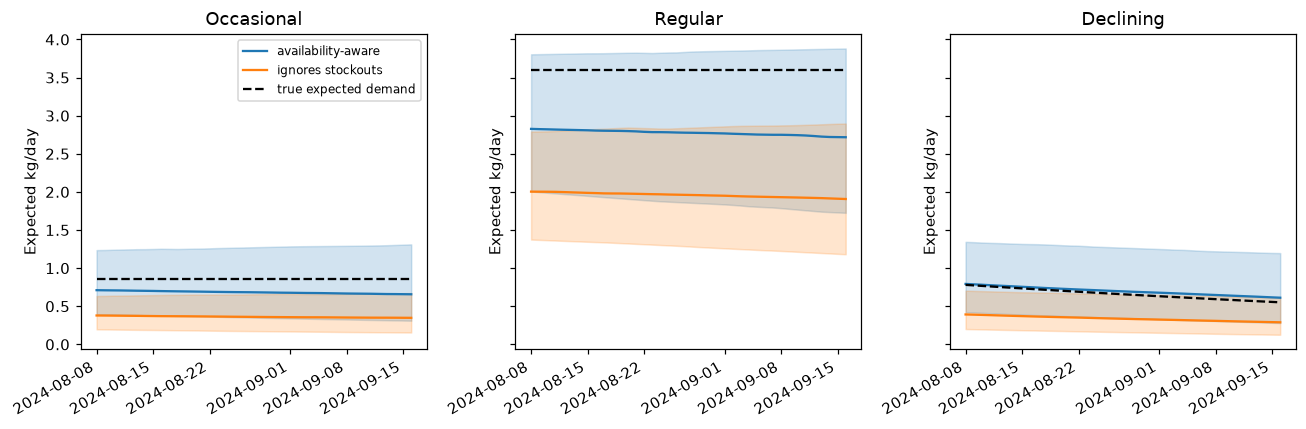

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, product in zip(axes, products, strict=True):
    for label, prediction, color in [
        ("availability-aware", full, "C0"),
        ("ignores stockouts", naive, "C1"),
    ]:
        mean = prediction.mu_future.sel(product=product)
        q = mean.quantile([0.05, 0.5, 0.95], dim=("chain", "draw"))
        ax.fill_between(
            time[n_train:], q.sel(quantile=0.05), q.sel(quantile=0.95), alpha=0.2, color=color
        )
        ax.plot(time[n_train:], q.sel(quantile=0.5), color=color, label=label)
    j = products.index(product)
    ax.plot(
        time[n_train:],
        probability[n_train:, j] * size_mean[j],
        color="black",
        ls="--",
        label="true expected demand",
    )
    ax.set(title=product, ylabel="Expected kg/day")
axes[0].legend(fontsize=8)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## Evaluate the business quantity you forecast

The table scores full-availability demand forecasts against simulated latent demand.
A sales forecast should instead be scored against sales under the specified availability.
These targets differ: low sales during stockouts do not establish that demand was low.
Short, intermittent holdouts also make aggregate CRPS and coverage variable; inspect
multiple origins and occurrence calibration before preferring a model.

The full-availability scenario estimates demand under the stated observation model.
It does not establish a causal effect of stocking decisions. The model assumes known,
external availability and does not cover noisy stockout labels or binding inventory caps.
See the [retail stockouts example](retail_stockouts.ipynb) for fractional availability.